# Эксперимент 17: Scale + Tricks

**Данные Эксп.13 + Техники Эксп.16**

| Источник | Что берём |
|---|---|
| **Эксп.13** | 778 реальных (200/класс, KMeans) + 2268 синтетических (`synth_pairs_exp13.pkl`) |
| **Эксп.16** | Lovász loss, AMP fp16 (batch 2→4), layer-wise LR decay |

| | Эксп.10 | Эксп.13 | Эксп.16 | **Эксп.17** |
|---|---|---|---|---|
| Реальных | 200 | **778** | 200 | **778** |
| Синтетики | 433 | **2268** | 433 | **2268** |
| Loss | CE+Dice | CE+Dice | **CE+Lovász** | **CE+Lovász** |
| Batch | 2 | 2 | **4 (AMP)** | **4 (AMP)** |
| LR backbone | единый | единый | **layer-wise** | **layer-wise** |
| mIoU | 0.5946 | 0.6411 | 0.6028 | **?** |

## 1. Импорты и конфигурация

In [1]:
import os, random, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5

INTERMEDIATE_LAYERS = [3, 5, 8, 11]

# ── Данные (Эксп.13) ──────────────────────────────────────────────────
N_PER_CLASS = 200       # 200 изображений на каждый класс → ~778 уникальных
TEST_SIZE   = 0.2
SYNTH_WEIGHT = 0.5

# ── Техники (Эксп.16) ─────────────────────────────────────────────────
N_UNFREEZE  = 4         # блоки 8-11
LR_BACKBONE = 1e-5      # базовый LR для блока 11
LR_DECAY    = 0.75      # множитель LR на каждый блок вниз
LR_HEAD     = 1e-3
BATCH_SIZE  = 4         # было 2 → за счёт AMP
EPOCHS      = 75

FLIP_P     = 0.5
CROP_SCALE = (0.85, 1.0)
BRIGHTNESS = 0.3

USE_AMP = (DEVICE == 'cuda')

print(f'\nВход:              {IMG_H}x{IMG_W}')
print(f'Слои DPT:          {INTERMEDIATE_LAYERS}')
print(f'Разморожено:       {N_UNFREEZE} блоков ({12-N_UNFREEZE}-11)')
print(f'LR backbone:       {LR_BACKBONE:.0e} (блок 11), decay={LR_DECAY}')
print(f'  Блок 11: {LR_BACKBONE:.1e}')
print(f'  Блок 10: {LR_BACKBONE*LR_DECAY:.2e}')
print(f'  Блок  9: {LR_BACKBONE*LR_DECAY**2:.2e}')
print(f'  Блок  8: {LR_BACKBONE*LR_DECAY**3:.2e}')
print(f'Batch size:        {BATCH_SIZE}  (AMP={USE_AMP})')
print(f'N_PER_CLASS:       {N_PER_CLASS}  → ожидается ~778 реальных')
print(f'Synth cache:       synth_pairs_exp13.pkl  (2268 пар)')

PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

Вход:              224x1400
Слои DPT:          [3, 5, 8, 11]
Разморожено:       4 блоков (8-11)
LR backbone:       1e-05 (блок 11), decay=0.75
  Блок 11: 1.0e-05
  Блок 10: 7.50e-06
  Блок  9: 5.63e-06
  Блок  8: 4.22e-06
Batch size:        4  (AMP=True)
N_PER_CLASS:       200  → ожидается ~778 реальных
Synth cache:       synth_pairs_exp13.pkl  (2268 пар)


## 2. Данные и вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов:')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


classes_cache = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: sorted(x.dropna().astype(int).unique().tolist())
).to_dict()
label_map = {img_id: (cls_list[0] if cls_list else 0)
             for img_id, cls_list in classes_cache.items()}

print('Функции определены.')

Строк: 7,095  |  Изображений: 6,666
Функции определены.


## 3. Dataset (с поддержкой синтетики)

In [3]:
class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h        = img_h
        self.img_w        = img_w
        self.is_train     = is_train
        self.flip_p       = flip_p
        self.crop_scale   = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor    = transforms.ToTensor()
        self.normalize    = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir; self.df=df; self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, 0


class SteelSegDatasetWithSynth(Dataset):
    def __init__(self, real_ids, img_dir, df, joint_transform, synth_pairs):
        self.real_ids = real_ids
        self.img_dir  = img_dir
        self.df       = df
        self.jt       = joint_transform
        self.synth    = synth_pairs
        self.n_real   = len(real_ids)
        self.n_synth  = len(synth_pairs)
    def __len__(self): return self.n_real + self.n_synth
    def __getitem__(self, idx):
        if idx < self.n_real:
            img_id   = self.real_ids[idx]
            img      = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
            mask     = build_segmask(img_id, self.df)
            is_synth = 0
        else:
            img_np, mask = self.synth[idx - self.n_real]
            img          = Image.fromarray(img_np.astype(np.uint8))
            is_synth     = 1
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, is_synth


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)
print(f'Datasets определены. Маска: {MASK_H}x{MASK_W}')

Datasets определены. Маска: 64x400


## 4. Загрузка DINOv2 — разморозка блоков 8–11

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE)

for p in dinov2.parameters():
    p.requires_grad = False

n_blocks      = len(dinov2.blocks)        # 12
unfreeze_from = n_blocks - N_UNFREEZE     # 8

for i, block in enumerate(dinov2.blocks):
    if i >= unfreeze_from:
        for p in block.parameters():
            p.requires_grad = True

for p in dinov2.norm.parameters():
    p.requires_grad = True

frozen    = sum(p.numel() for p in dinov2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in dinov2.parameters() if p.requires_grad)
print(f'DINOv2 ViT-B/14: {(frozen+trainable)/1e6:.1f}М параметров')
print(f'  Заморожено:  {frozen/1e6:.1f}М  (блоки 0–{unfreeze_from-1})')
print(f'  Разморожено: {trainable/1e6:.1f}М  (блоки {unfreeze_from}–{n_blocks-1} + norm)')

with torch.no_grad():
    test_img = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    feats = dinov2.get_intermediate_layers(
        test_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
    assert all(f.shape == (1, PATCH_H*PATCH_W, EMBED_DIM) for f in feats)
    print(f'Forward check: OK  ({len(feats)} слоёв x {feats[0].shape})')
del test_img, feats

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM свободно: {free/1e9:.1f} ГБ / {total/1e9:.1f} ГБ')

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров
  Заморожено:  58.2М  (блоки 0–7)
  Разморожено: 28.4М  (блоки 8–11 + norm)
Forward check: OK  (4 слоёв x torch.Size([1, 1600, 768]))
VRAM свободно: 6.8 ГБ / 8.5 ГБ


## 5. Эмбеддинги (из кэша)

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')
if os.path.exists(emb_cache):
    print('Загружаем из кэша...')
    ckpt       = torch.load(emb_cache, map_location='cpu')
    embeddings = ckpt['embeddings']
    emb_ids    = ckpt['emb_ids']
    print(f'Загружено: {embeddings.shape}')
else:
    print('Кэш не найден — извлекаем...')
    sq_t = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    class _EmbDs(Dataset):
        def __init__(self, ids, d, t): self.ids=ids; self.d=d; self.t=t
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.d, self.ids[i])).convert('RGB')
            return self.t(img), self.ids[i]
    ds = _EmbDs(labeled_ids, TRAIN_IMG_DIR, sq_t)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    embs, ids_out = [], []
    dinov2.eval()
    with torch.no_grad():
        for imgs, img_ids in tqdm(dl, desc='Эмбеддинги'):
            tok = dinov2.forward_features(imgs.to(DEVICE))['x_norm_clstoken']
            embs.append(tok.cpu()); ids_out.extend(img_ids)
    embeddings = torch.cat(embs, 0); emb_ids = ids_out
    torch.save({'embeddings': embeddings, 'emb_ids': emb_ids}, emb_cache)
    print(f'Сохранено: {embeddings.shape}')

emb_id_to_idx = {v: k for k, v in enumerate(emb_ids)}

Загружаем из кэша...
Загружено: torch.Size([6666, 768])


## 6. Отбор изображений: 200 на каждый класс (как Эксп.13)

KMeans в пространстве эмбеддингов DINOv2 → ~778 уникальных реальных изображений.

In [6]:
all_labels = [label_map.get(i, 0) for i in labeled_ids]
train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')


def kmeans_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    selected = []
    for k in range(n_select):
        m = km.labels_ == k
        if not m.any(): continue
        center  = torch.tensor(km.cluster_centers_[k])
        ix      = np.where(m)[0]
        nearest = int(ix[torch.norm(embeddings[m] - center, dim=1).argmin().item()])
        selected.append(image_ids[nearest])
    return selected


def select_per_class(embeddings, image_ids, classes_cache,
                     n_per_class=N_PER_CLASS, seed=SEED):
    image_id_to_idx = {v: k for k, v in enumerate(image_ids)}
    selected_set    = set()
    per_class_info  = {}
    for cls in [1, 2, 3, 4]:
        cls_ids = [i for i in image_ids if cls in classes_cache.get(i, [])]
        n_avail = len(cls_ids)
        if n_avail == 0:
            print(f'  Класс {cls}: нет изображений!')
            per_class_info[cls] = []; continue
        if n_avail <= n_per_class:
            chosen = cls_ids
            print(f'  Класс {cls}: {n_avail} доступно < {n_per_class} → берём все')
        else:
            idxs       = [image_id_to_idx[i] for i in cls_ids]
            cls_embeds = embeddings[idxs]
            chosen     = kmeans_select(cls_embeds, cls_ids, n_per_class, seed)
            print(f'  Класс {cls}: {n_avail} доступно → {len(chosen)} отобрано (KMeans)')
        per_class_info[cls] = chosen
        selected_set.update(chosen)
    result = list(selected_set)
    multi  = sum(1 for i in result if len(classes_cache.get(i, [])) > 1)
    print(f'\nИтого уникальных: {len(result)}  (из них с 2+ классами: {multi})')
    return result, per_class_info


pool_mask    = [emb_id_to_idx[i] for i in train_ids]
pool_embeds  = embeddings[pool_mask]

print('Отбор 200 изображений на класс:')
selected_ids, per_class = select_per_class(
    pool_embeds, train_ids, classes_cache, n_per_class=N_PER_CLASS)

overlap = set(selected_ids) & set(test_ids)
assert len(overlap) == 0, f'ОШИБКА: пересечение с тест-сетом!'
print(f'Пересечений с тест-сетом: 0 ✓')

Train pool: 5,332  |  Test: 1,334
Отбор 200 изображений на класс:
  Класс 1: 717 доступно → 200 отобрано (KMeans)
  Класс 2: 197 доступно < 200 → берём все
  Класс 3: 4113 доступно → 200 отобрано (KMeans)
  Класс 4: 641 доступно → 200 отобрано (KMeans)

Итого уникальных: 778  (из них с 2+ классами: 159)
Пересечений с тест-сетом: 0 ✓


## 7. Архитектура: SegHeadDPT + Lovász-Softmax

**Lovász-Softmax** (Berman et al., CVPR 2018) — дифференцируемый суррогат IoU.  
Итоговый лосс: `CE(weighted) + Lovász`.

In [7]:
class SegHeadDPT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers
        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, 256, 1),
                nn.BatchNorm2d(256), nn.GELU(),
            ) for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1),
            nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
            maps.append(self.proj[i](x))
        x = torch.cat(maps, dim=1)
        x = self.fuse(x)
        x = self.up1(x)
        x = self.up2(x)
        return self.head(x)


# ── Lovász-Softmax ────────────────────────────────────────────────────

def _lovász_grad(gt_sorted):
    n   = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union        = gts + (1.0 - gt_sorted).float().cumsum(0)
    jaccard      = 1.0 - intersection / union
    if n > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]
    return jaccard


def _lovász_softmax_flat(probas, labels):
    C = probas.size(1)
    losses = []
    for c in range(C):
        fg = (labels == c).float()
        if fg.sum() == 0:
            continue
        errors = (fg - probas[:, c]).abs()
        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, _lovász_grad(fg_sorted)))
    if not losses:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()


class LovászSoftmax(nn.Module):
    """Multi-class Lovász-Softmax. Внутри fp32 — безопасно в autocast."""
    def forward(self, logits, targets):
        B, C, H, W = logits.shape
        probas  = F.softmax(logits.float(), dim=1)
        probas  = probas.permute(0, 2, 3, 1).reshape(-1, C)
        targets = targets.reshape(-1)
        return _lovász_softmax_flat(probas, targets)


_h = SegHeadDPT().to(DEVICE)
print(f'SegHeadDPT:     {sum(p.numel() for p in _h.parameters()):,} параметров')
del _h
print('LovászSoftmax:  реализован с нуля (без внешних зависимостей)')

SegHeadDPT:     2,845,381 параметров
LovászSoftmax:  реализован с нуля (без внешних зависимостей)


## 8. Синтетика (кэш из Эксп.13)

In [8]:
synth_cache = os.path.join(save_dir, 'synth_pairs_exp13.pkl')

if not os.path.exists(synth_cache):
    raise FileNotFoundError(
        f'Кэш синтетики не найден: {synth_cache}\n'
        'Сначала запустите Experiment13_ScaleLabels.ipynb до ячейки 8.'
    )

print('Загружаем синтетику из кэша Эксп.13...')
with open(synth_cache, 'rb') as f:
    synth_pairs = pickle.load(f)

n_synth = len(synth_pairs)
print(f'Загружено: {n_synth} синтетических пар (классы 1 и 2)')
print(f'Итого: {len(selected_ids)} реальных + {n_synth} синтетических '
      f'= {len(selected_ids) + n_synth} изображений')

Загружаем синтетику из кэша Эксп.13...
Загружено: 2268 синтетических пар (классы 1 и 2)
Итого: 778 реальных + 2268 синтетических = 3046 изображений


## 9. Layer-wise LR decay — группы параметров

Блок 11: `1e-5`, блок 10: `7.5e-6`, блок 9: `5.6e-6`, блок 8: `4.2e-6`.

In [9]:
def make_backbone_param_groups(model, base_lr=LR_BACKBONE, decay=LR_DECAY,
                                n_unfreeze=N_UNFREEZE, weight_decay=1e-2):
    nb = len(model.blocks)
    unfreeze_from = nb - n_unfreeze
    groups = []
    norm_params = [p for p in model.norm.parameters() if p.requires_grad]
    if norm_params:
        groups.append({'params': norm_params, 'lr': base_lr,
                       'weight_decay': weight_decay, 'name': 'norm'})
    for i in range(nb - 1, unfreeze_from - 1, -1):
        block_params = [p for p in model.blocks[i].parameters() if p.requires_grad]
        if not block_params: continue
        depth = nb - 1 - i
        lr_i  = base_lr * (decay ** depth)
        groups.append({'params': block_params, 'lr': lr_i,
                       'weight_decay': weight_decay, 'name': f'block_{i}'})
    return groups


preview = make_backbone_param_groups(dinov2)
print('Layer-wise LR backbone:')
for g in preview:
    n_p = sum(p.numel() for p in g['params'])
    print(f'  {g["name"]:<10}  LR={g["lr"]:.2e}  params={n_p/1e6:.2f}М')
total_bb = sum(sum(p.numel() for p in g['params']) for g in preview)
print(f'  Итого backbone: {total_bb/1e6:.1f}М')
print(f'  + head:         ~2.8М')

Layer-wise LR backbone:
  norm        LR=1.00e-05  params=0.00М
  block_11    LR=1.00e-05  params=7.09М
  block_10    LR=7.50e-06  params=7.09М
  block_9     LR=5.63e-06  params=7.09М
  block_8     LR=4.22e-06  params=7.09М
  Итого backbone: 28.4М
  + head:         ~2.8М


## 10. Функция обучения (AMP + Lovász + layer-wise LR)

In [10]:
def train_finetune(train_ids, val_ids, df, synth_pairs=None,
                   n_epochs=EPOCHS, label='ft_exp17',
                   checkpoint_every=25):

    head = SegHeadDPT().to(DEVICE)

    bb_groups  = make_backbone_param_groups(dinov2)
    head_group = [{'params': list(head.parameters()),
                   'lr': LR_HEAD, 'weight_decay': 1e-4, 'name': 'head'}]
    opt   = optim.AdamW(bb_groups + head_group)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    cw   = compute_class_weights(train_ids, df)
    cce  = nn.CrossEntropyLoss(weight=cw, reduction='none')
    clov = LovászSoftmax()

    if synth_pairs is not None:
        tds = SteelSegDatasetWithSynth(
            train_ids, TRAIN_IMG_DIR, df, train_jt, synth_pairs)
    else:
        tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)

    vds = SteelSegDataset(val_ids, TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    best_state_head = None
    best_state_bb   = None

    total_bb = sum(sum(p.numel() for p in g['params']) for g in bb_groups)
    total_hd = sum(p.numel() for p in head.parameters())
    print(f'Обучаемых: backbone {total_bb/1e6:.1f}М + head {total_hd/1e3:.0f}К')
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    if synth_pairs:
        print(f'  реальных: {len(train_ids)}, синтетических: {len(synth_pairs)}')
    print(f'AMP: {USE_AMP}  |  Batch: {BATCH_SIZE}  |  Батчей/эпоху: {len(tdl)}')

    for ep in range(1, n_epochs + 1):
        dinov2.eval()
        for i, block in enumerate(dinov2.blocks):
            if i >= (n_blocks - N_UNFREEZE):
                block.train()
        dinov2.norm.train()
        head.train()

        tl = 0.0
        for imgs, masks, is_synth in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()

            if scaler is not None:
                with torch.amp.autocast('cuda'):
                    feats = dinov2.get_intermediate_layers(
                        imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                    lg = head(feats)
                    pixel_loss = cce(lg, masks)
                    w_batch = torch.where(
                        is_synth.bool().to(DEVICE)[:, None, None],
                        torch.full_like(pixel_loss, SYNTH_WEIGHT),
                        torch.ones_like(pixel_loss)
                    )
                    ce_loss  = (pixel_loss * w_batch).mean()
                    lov_loss = clov(lg, masks)
                    loss = ce_loss + lov_loss
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                feats = dinov2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                lg = head(feats)
                pixel_loss = cce(lg, masks)
                w_batch = torch.where(
                    is_synth.bool().to(DEVICE)[:, None, None],
                    torch.full_like(pixel_loss, SYNTH_WEIGHT),
                    torch.ones_like(pixel_loss)
                )
                loss = (pixel_loss * w_batch).mean() + clov(lg, masks)
                loss.backward()
                opt.step()

            tl += loss.item()
        sched.step()

        dinov2.eval(); head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                if USE_AMP:
                    with torch.amp.autocast('cuda'):
                        feats = dinov2.get_intermediate_layers(
                            imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                        preds = head(feats).argmax(1)
                else:
                    feats = dinov2.get_intermediate_layers(
                        imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                    preds = head(feats).argmax(1)
                iou.update(preds, masks)

        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl / len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())

        if mi > best:
            best = mi
            best_state_head = {k: v.clone() for k, v in head.state_dict().items()}
            best_state_bb   = {k: v.clone() for k, v in dinov2.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i, v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_ep{ep}.pt')
            torch.save({'epoch': ep, 'head_state': head.state_dict(),
                        'backbone_state': dinov2.state_dict(),
                        'history': hist, 'best_miou': best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    head.load_state_dict(best_state_head)
    dinov2.load_state_dict(best_state_bb)
    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 11. Обучение

In [11]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM занято:   {torch.cuda.memory_allocated()/1e9:.1f} Гб')
    print(f'VRAM свободно: {free/1e9:.1f} Гб  /  {total/1e9:.1f} Гб')

print('='*75)
print(f'ЭКСП.17: {len(selected_ids)} реал. + {len(synth_pairs)} синт. | '
      f'batch={BATCH_SIZE} | AMP={USE_AMP}')
print(f'  Loss: CE(weighted) + Lovász')
print(f'  LR:   layer-wise decay {LR_BACKBONE:.0e} → {LR_BACKBONE*LR_DECAY**3:.2e}')
print('='*75)

model_17, history_17 = train_finetune(
    selected_ids, test_ids, train_df,
    synth_pairs=synth_pairs,
    label='ft_exp17'
)

VRAM занято:   0.4 Гб
VRAM свободно: 6.9 Гб  /  8.5 Гб
ЭКСП.17: 778 реал. + 2268 синт. | batch=4 | AMP=True
  Loss: CE(weighted) + Lovász
  LR:   layer-wise decay 1e-05 → 4.22e-06
Веса классов:
  Фон: 0.100  (301,878,692 пикс.)
  Дефект 1: 1.946  (882,239 пикс.)
  Дефект 2: 2.597  (661,191 пикс.)
  Дефект 3: 0.214  (8,021,328 пикс.)
  Дефект 4: 0.238  (7,225,350 пикс.)
Обучаемых: backbone 28.4М + head 2845К
Обучающих: 3046  |  Валидационных: 1334
  реальных: 778, синтетических: 2268
AMP: True  |  Batch: 4  |  Батчей/эпоху: 762
[ft_exp17] Эп   1/75 | Loss:0.4980 | mIoU:0.4469 | cls0:0.954  cls1:0.114  cls2:0.031  cls3:0.514  cls4:0.621
[ft_exp17] Эп  10/75 | Loss:0.2909 | mIoU:0.6092 | cls0:0.969  cls1:0.423  cls2:0.370  cls3:0.607  cls4:0.677
[ft_exp17] Эп  20/75 | Loss:0.2411 | mIoU:0.6027 | cls0:0.974  cls1:0.442  cls2:0.265  cls3:0.643  cls4:0.689
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_ft_exp17_ep25.pt
[ft_exp17] Эп  30/75 | Loss:0.2086 | mIoU:0.6312 | cls0:0

## 12. Сравнение с предыдущими экспериментами

ИТОГОВОЕ СРАВНЕНИЕ:
  Эксп.9  (4 бл., без синт.)                : mIoU = 0.5406
  Эксп.14 (6 бл., 200 реал.)                : mIoU = 0.5840
  Эксп.12 (4 бл., +аугм.)                   : mIoU = 0.5903
  Эксп.10 (4 бл., 200 реал.+433 синт.)      : mIoU = 0.5946
  Эксп.16 (Lovász+AMP, 200 реал.)           : mIoU = 0.6028
  Эксп.13 (778 реал.+2268 синт.)            : mIoU = 0.6411
  Эксп.17 (Lovász+AMP+LayerLR, 778+2268)    : mIoU = 0.6756 <-- ЛУЧШИЙ

  Прирост vs Эксп.10 (базис):        +8.1%
  Прирост vs Эксп.13 (+данные):      +3.4%
  Прирост vs Эксп.16 (+техники):     +7.3%

  Класс           Эксп.10 (  Эксп.13 (  Эксп.16 (    Эксп.17
  ----------------------------------------------------------
  Фон                0.9679     0.9738     0.9708     0.9772
  Дефект 1           0.3858     0.4757     0.3774     0.5280
  Дефект 2           0.3949     0.4170     0.3999     0.4652
  Дефект 3           0.5913     0.6553     0.5970     0.6803
  Дефект 4           0.6330     0.6839     0.6692   

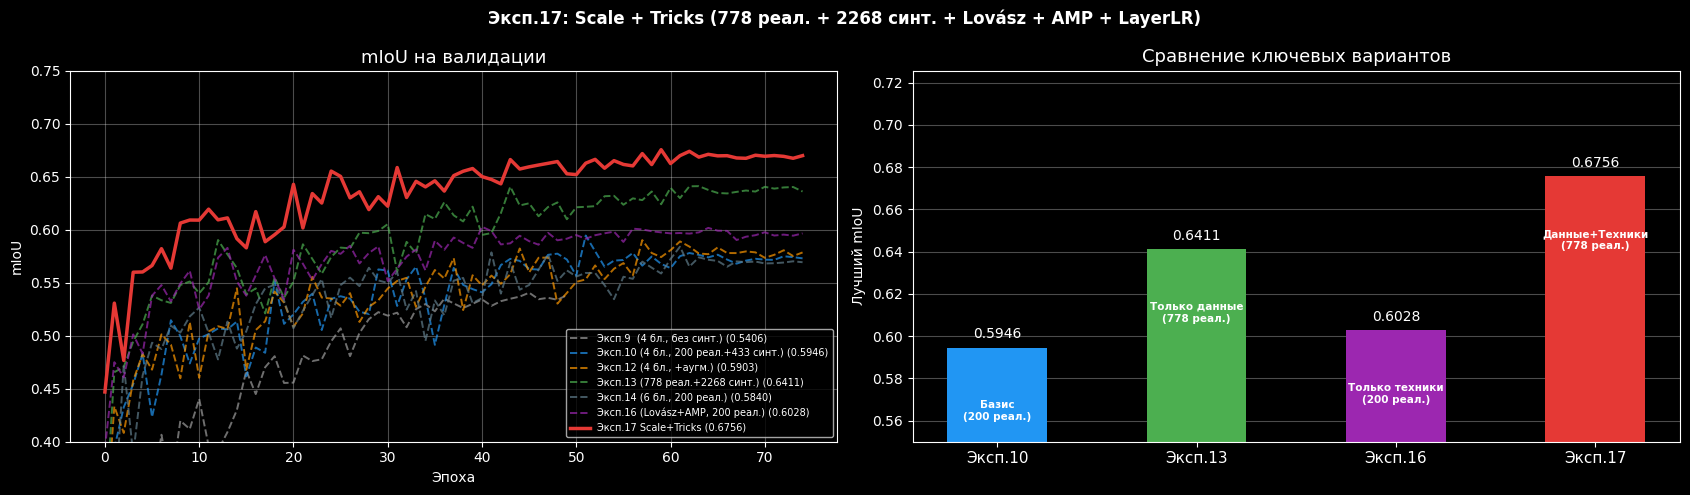

In [12]:
names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']

m_17 = max(history_17['val_miou'])
e_17 = int(np.argmax(history_17['val_miou']))
i_17 = history_17['val_iou_per_class'][e_17]

results = {}
for name, fname in [
    ('Эксп.9  (4 бл., без синт.)',          'history_ft_dpt_v2.json'),
    ('Эксп.10 (4 бл., 200 реал.+433 синт.)', 'history_ft_dpt_synth_v2.json'),
    ('Эксп.12 (4 бл., +аугм.)',              'history_ft_dpt_aug.json'),
    ('Эксп.13 (778 реал.+2268 синт.)',        'history_exp13.json'),
    ('Эксп.14 (6 бл., 200 реал.)',            'history_exp14_6blocks.json'),
    ('Эксп.16 (Lovász+AMP, 200 реал.)',       'history_exp16.json'),
]:
    p = os.path.join(save_dir, fname)
    if os.path.exists(p):
        with open(p) as f:
            h = json.load(f)
        m = max(h['val_miou'])
        e = int(np.argmax(h['val_miou']))
        results[name] = {'miou': m, 'iou': h['val_iou_per_class'][e], 'hist': h}

print('ИТОГОВОЕ СРАВНЕНИЕ:')
all_res = dict(results)
all_res['Эксп.17 (Lovász+AMP+LayerLR, 778+2268)'] = {
    'miou': m_17, 'iou': i_17, 'hist': history_17}

for name, r in sorted(all_res.items(), key=lambda x: x[1]['miou']):
    marker = ' <-- ЛУЧШИЙ' if r['miou'] == max(v['miou'] for v in all_res.values()) else ''
    print(f'  {name:<42}: mIoU = {r["miou"]:.4f}{marker}')

ref10 = results.get('Эксп.10 (4 бл., 200 реал.+433 синт.)')
ref13 = results.get('Эксп.13 (778 реал.+2268 синт.)')
ref16 = results.get('Эксп.16 (Lovász+AMP, 200 реал.)')
if ref10:
    print(f'\n  Прирост vs Эксп.10 (базис):        {(m_17 - ref10["miou"])*100:+.1f}%')
if ref13:
    print(f'  Прирост vs Эксп.13 (+данные):      {(m_17 - ref13["miou"])*100:+.1f}%')
if ref16:
    print(f'  Прирост vs Эксп.16 (+техники):     {(m_17 - ref16["miou"])*100:+.1f}%')

# IoU по классам
print(f'\n  {"Класс":<14}', end='')
key_names = ['Эксп.10 (4 бл., 200 реал.+433 синт.)',
             'Эксп.13 (778 реал.+2268 синт.)',
             'Эксп.16 (Lovász+AMP, 200 реал.)']
shown = {k: all_res[k] for k in key_names if k in all_res}
shown['Эксп.17'] = all_res['Эксп.17 (Lovász+AMP+LayerLR, 778+2268)']
for k in shown:
    print(f'{k[:9]:>11}', end='')
print()
print('  ' + '-'*(14 + 11*len(shown)))
for c in range(NUM_CLASSES):
    print(f'  {names[c]:<14}', end='')
    for r in shown.values():
        print(f'{r["iou"][c]:>11.4f}', end='')
    print()

# Графики
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

palette = ['#9E9E9E','#2196F3','#FF9800','#4CAF50','#607D8B','#9C27B0']
for (name, r), col in zip(results.items(), palette):
    axes[0].plot(r['hist']['val_miou'], color=col, lw=1.4, alpha=0.7,
                 ls='--', label=f'{name} ({r["miou"]:.4f})')
axes[0].plot(history_17['val_miou'], color='#E53935', lw=2.5,
             label=f'Эксп.17 Scale+Tricks ({m_17:.4f})')
axes[0].set_title('mIoU на валидации', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0.4, 0.75)

# Bar chart ключевых экспериментов
bar_data = [
    ('Эксп.10', results.get('Эксп.10 (4 бл., 200 реал.+433 синт.)'), '#2196F3'),
    ('Эксп.13', results.get('Эксп.13 (778 реал.+2268 синт.)'),        '#4CAF50'),
    ('Эксп.16', results.get('Эксп.16 (Lovász+AMP, 200 реал.)'),       '#9C27B0'),
    ('Эксп.17', all_res['Эксп.17 (Lovász+AMP+LayerLR, 778+2268)'],    '#E53935'),
]
bar_data = [(n, r, c) for n, r, c in bar_data if r is not None]
bar_names = [x[0] for x in bar_data]
bar_vals  = [x[1]['miou'] for x in bar_data]
bar_cols  = [x[2] for x in bar_data]

bars = axes[1].bar(range(len(bar_vals)), bar_vals, color=bar_cols, width=0.5, zorder=2)
axes[1].set_xticks(range(len(bar_names)))
axes[1].set_xticklabels(bar_names, fontsize=11)
axes[1].set_ylabel('Лучший mIoU')
axes[1].set_title('Сравнение ключевых вариантов', fontsize=13)
axes[1].set_ylim(0.55, max(bar_vals) + 0.05)
axes[1].grid(True, axis='y', alpha=0.3, zorder=1)
for bar, val in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Подписи
labels_bar = ['Базис\n(200 реал.)','Только данные\n(778 реал.)','Только техники\n(200 реал.)','Данные+Техники\n(778 реал.)']
for i, lbl in enumerate(labels_bar[:len(bar_names)]):
    axes[1].text(i, bar_vals[i] - 0.025, lbl,
                 ha='center', va='top', fontsize=7.5, color='white', fontweight='bold')

plt.suptitle('Эксп.17: Scale + Tricks (778 реал. + 2268 синт. + Lovász + AMP + LayerLR)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 13. Сохранение

In [13]:
torch.save(model_17.state_dict(),
           os.path.join(save_dir, 'model_exp17.pt'))
torch.save(dinov2.state_dict(),
           os.path.join(save_dir, 'dinov2_exp17.pt'))
with open(os.path.join(save_dir, 'history_exp17.json'), 'w') as f:
    json.dump(history_17, f)

print('Сохранено:')
print('  model_exp17.pt      — голова DPT')
print('  dinov2_exp17.pt     — backbone')
print('  history_exp17.json  — история обучения')
print(f'\nЛучший mIoU Эксп.17: {m_17:.4f}  (эпоха {e_17+1})')
print(f'IoU по классам: {[f"{v:.3f}" for v in i_17]}')
if ref10:
    print(f'\nПрирост vs Эксп.10 (базис):    {(m_17 - ref10["miou"])*100:+.1f}%')
if ref13:
    print(f'Прирост vs Эксп.13 (+данные):  {(m_17 - ref13["miou"])*100:+.1f}%')
if ref16:
    print(f'Прирост vs Эксп.16 (+техники): {(m_17 - ref16["miou"])*100:+.1f}%')

Сохранено:
  model_exp17.pt      — голова DPT
  dinov2_exp17.pt     — backbone
  history_exp17.json  — история обучения

Лучший mIoU Эксп.17: 0.6756  (эпоха 60)
IoU по классам: ['0.977', '0.528', '0.465', '0.680', '0.727']

Прирост vs Эксп.10 (базис):    +8.1%
Прирост vs Эксп.13 (+данные):  +3.4%
Прирост vs Эксп.16 (+техники): +7.3%
